In [1]:
#import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style("whitegrid")
%matplotlib inline

In [2]:
# load the raw data 
df = pd.read_csv("../data/raw/Telco-Customer-Churn.csv")
print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
#inspect data types and nulls
df.info()
print("Nulls per column:")
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
# Fixing column of 'total charges'
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["tenure"] * df["MonthlyCharges"])
print("Remaining nulls in TotalCharges:", df["TotalCharges"].isnull().sum())
print("Data type now:", df["TotalCharges"].dtype)

Remaining nulls in TotalCharges: 0
Data type now: float64


In [5]:
# Encode churn
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})
print(df["Churn"].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [6]:
# Drop 'customerID' and create features
df = df.drop(columns=["customerID"], errors="ignore")

# 1.Average charges per month
df["AvgChargesPerMonth"] = df["TotalCharges"] / df["tenure"].replace(0, 1)

# 2.Charge ratio
df["ChargeRatio"] = df["MonthlyCharges"] / df["AvgChargesPerMonth"].replace(0, 1)

# 3. Service count
service_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
                "TechSupport", "StreamingTV", "StreamingMovies"]
df["NumServices"] = (df[service_cols] == "Yes").sum(axis=1)

# 4. Lifecycle flags
df["IsNewCustomer"] = (df["tenure"] <= 6).astype(int)
df["HasFamily"] = ((df["Partner"] == "Yes") | (df["Dependents"] == "Yes")).astype(int)

# 5. Contract risk
df["ContractRisk"] = df["Contract"].map({
    "Month-to-month": 2, "One year": 1, "Two year": 0
})

# 6. Payment risk
df["PaymentRisk"] = df["PaymentMethod"].apply(
    lambda x: 2 if "Electronic check" in x else (0 if "automatic" in x else 1)
)

print("New shape:", df.shape)

New shape: (7043, 27)


In [7]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,MonthlyCharges,TotalCharges,Churn,AvgChargesPerMonth,ChargeRatio,NumServices,IsNewCustomer,HasFamily,ContractRisk,PaymentRisk
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,29.85,29.85,0,29.850000,1.000000,1,1,1,2,2
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,56.95,1889.50,0,55.573529,1.024768,2,0,0,1,1
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,53.85,108.15,1,54.075000,0.995839,2,1,0,2,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,42.30,1840.75,0,40.905556,1.034089,3,0,0,1,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,70.70,151.65,1,75.825000,0.932410,0,1,0,2,2


In [8]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,AvgChargesPerMonth,ChargeRatio,NumServices,IsNewCustomer,HasFamily,ContractRisk,PaymentRisk
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304,0.265370,64.698218,1.065434,2.037910,0.210280,0.534289,1.309527,0.900469
std,0.368612,24.559481,30.090047,2266.794470,0.441561,30.270670,1.832123,1.847682,0.407536,0.498858,0.833755,0.872538
min,0.000000,0.000000,18.250000,0.000000,0.000000,0.000000,0.635545,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,9.000000,35.500000,398.550000,0.000000,35.649000,0.980882,0.000000,0.000000,0.000000,1.000000,0.000000
50%,0.000000,29.000000,70.350000,1394.550000,0.000000,70.300000,1.000000,2.000000,0.000000,1.000000,2.000000,1.000000
75%,0.000000,55.000000,89.850000,3786.600000,1.000000,90.174158,1.021004,3.000000,0.000000,1.000000,2.000000,2.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000,121.400000,80.850000,6.000000,1.000000,1.000000,2.000000,2.000000


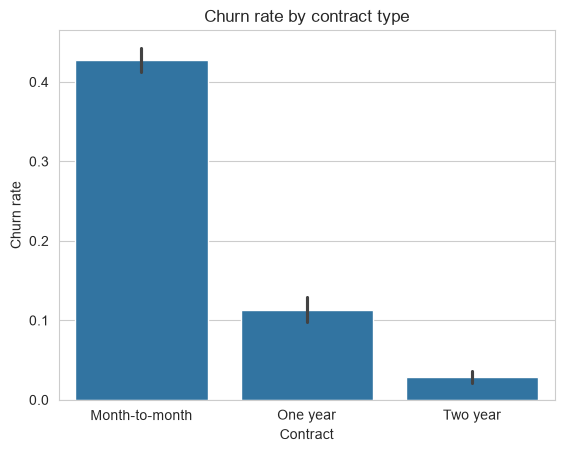

In [9]:
# EDA plots
sns.barplot(data=df, x="Contract", y="Churn")
plt.title("Churn rate by contract type")
plt.ylabel("Churn rate")
plt.show()

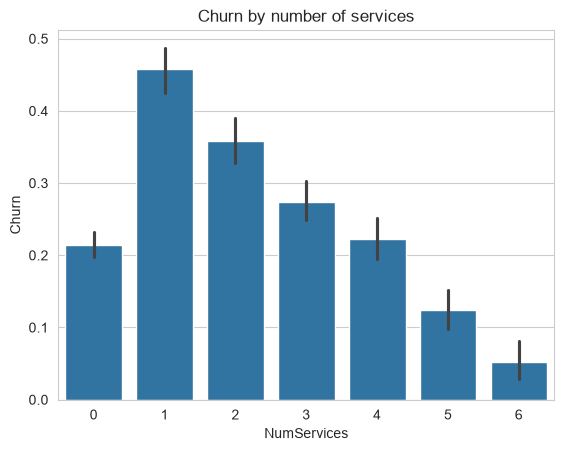

In [10]:
sns.barplot(data=df, x="NumServices", y="Churn")
plt.title("Churn by number of services")
plt.show()

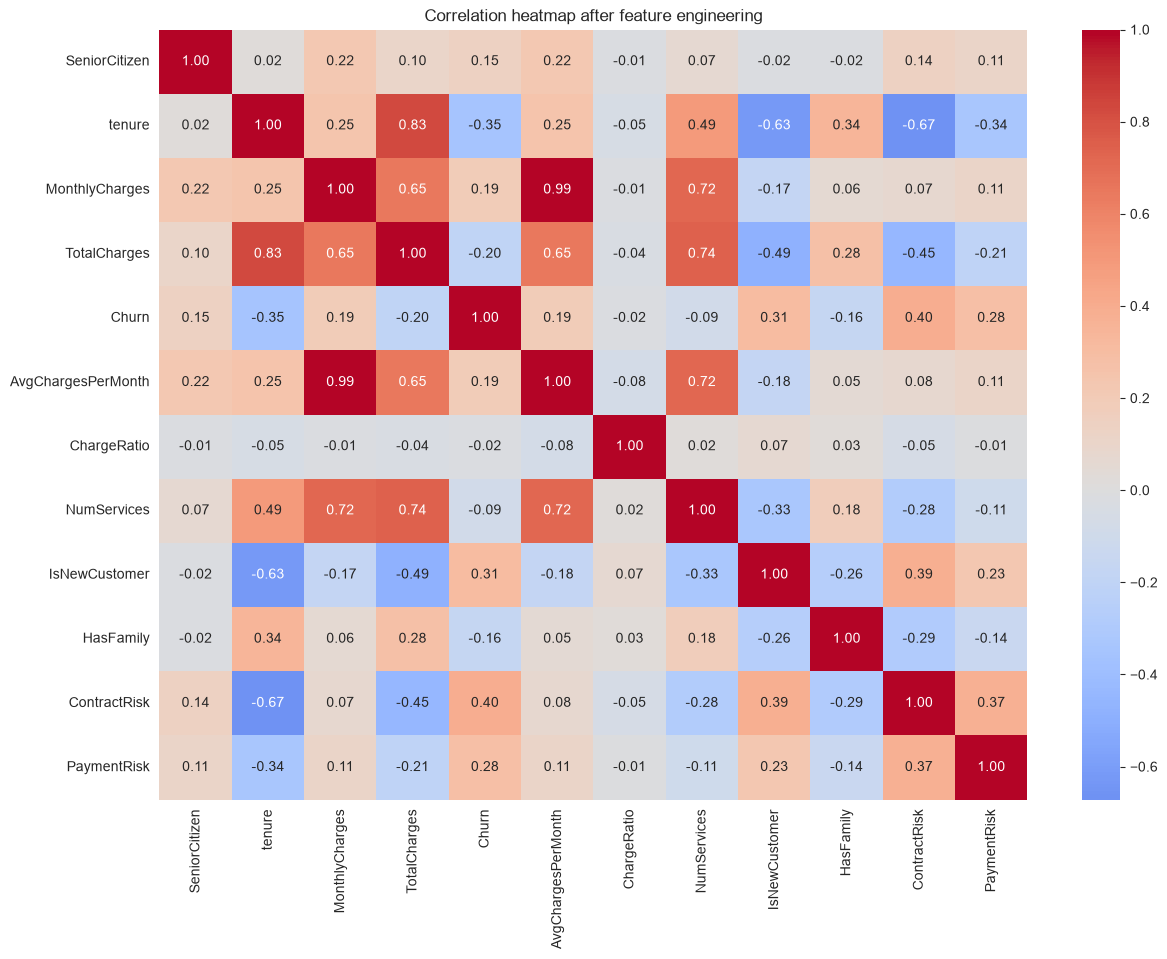

In [11]:
plt.figure(figsize=(14, 10))
numeric_df = df.select_dtypes(include=["int64", "float64"])
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation heatmap after feature engineering")
plt.show()

In [12]:
df.to_csv("../data/processed/features.csv", index=False)
print("Saved features.csv with shape:", df.shape)

Saved features.csv with shape: (7043, 27)
